# Снедков Валентин, ЕТ-128, "Разделительная кластеризация"

## Задание
1. Выполните кластеризацию набора 2-х или 3-мерных данных с помощью алгоритма k‑Means (предполагается, что полученные кластеры будут выпуклыми), используя различные значения параметра  (из интервала 3..9). Выполните визуализацию полученных результатов в виде точечных графиков, на которых цвет точки отражает принадлежность кластеру.
2. Внесите шум в набор данных (случайным образом изменить определенную долю объектов набора: 1%, 3%, 5%, 10%; изменение может заключаться в добавлении/вычитании к/из одной/нескольких координат объекта случайного числа). Выполните кластеризацию зашумленного набора данных с помощью алгоритмов k‑Means и k‑Medoids (или PAM), используя различные значения параметра  (из интервала 3..9). Выполните визуализацию полученных результатов в виде точечных графиков, на которых цвет точки отражает принадлежность кластеру.
3. Выполните кластеризацию набора данных из задания о плотностной кластеризации (с невыпуклыми кластерами) с помощью алгоритмов k‑Means и k‑Medoids (или PAM), используя различные значения параметра  (из интервала 3..9). Выполните визуализацию полученных результатов в виде точечных графиков, на которых цвет точки отражает принадлежность кластеру.
4. Подготовьте отчет о выполнении задания и загрузите отчет в формате PDF в систему. Отчет должен представлять собой связный и структурированный документ со следующими разделами:  
- формулировка задания;
- гиперссылка на каталог репозитория с исходными текстами, набором данных и др. сопутствующими материалами;
- рисунки с результатами визуализации;
- пояснения, раскрывающие смысл полученных результатов.

#### Начало работы

In [ ]:
!pip install "numpy<2"
!pip install scikit-learn-extra

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# 1. Кластеризация набора данных выпуклых кластеров на k-means с разным параметром k (от 3 до 9)

In [ ]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn_extra.cluster import KMedoids
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 10)

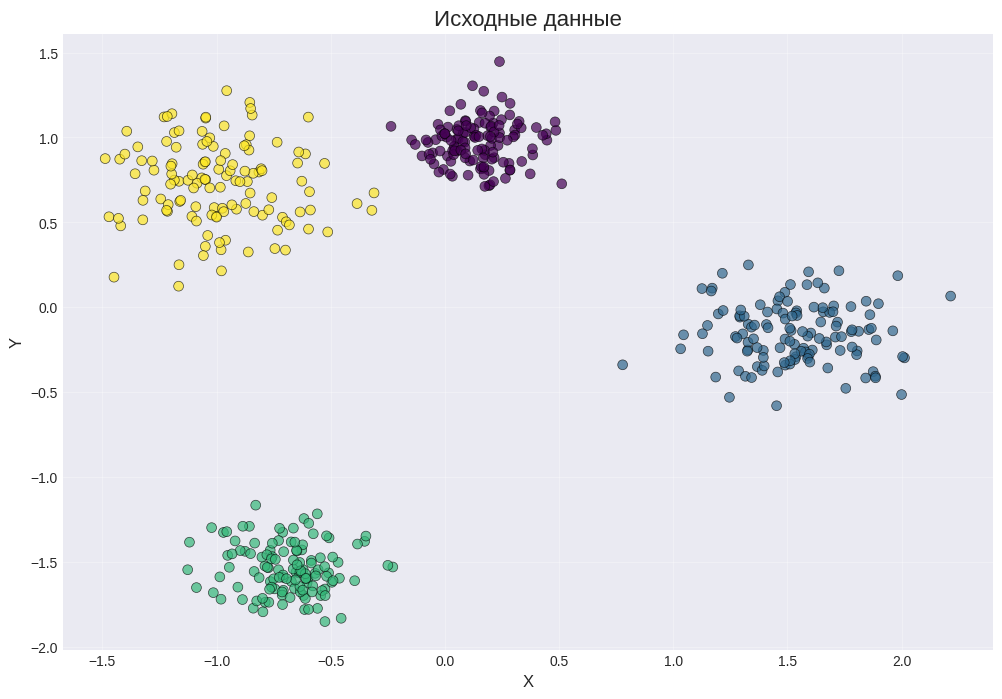

Размерность данных: (500, 2)
Количество точек: 500


In [ ]:
# Создаем набор данных с выпуклыми кластерами (круги)

np.random.seed(42)
X, y_true = make_blobs(n_samples=500,
                       centers=4,
                       cluster_std=[0.8, 1.2, 0.9, 1.5],
                       random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(12, 8))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true, cmap='viridis',
           s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
plt.title('Исходные данные', fontsize=16)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Размерность данных: {X_scaled.shape}")
print(f"Количество точек: {len(X_scaled)}")

In [ ]:
# Визуализация результатов
def plot_clustering_results(X, labels, centers=None, title="", ax=None):
    if ax is None:
        ax = plt.gca()

    unique_labels = np.unique(labels)
    colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))

    for k, col in zip(unique_labels, colors):
        class_member_mask = (labels == k)
        xy = X[class_member_mask]
        ax.scatter(xy[:, 0], xy[:, 1], c=[col], s=40, alpha=0.7,
                  edgecolors='white', linewidth=0.5)

    if centers is not None:
        ax.scatter(centers[:, 0], centers[:, 1], c='black', s=200,
                  marker='*', edgecolors='white', linewidth=2,
                  label='Центры кластеров')

    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.5)

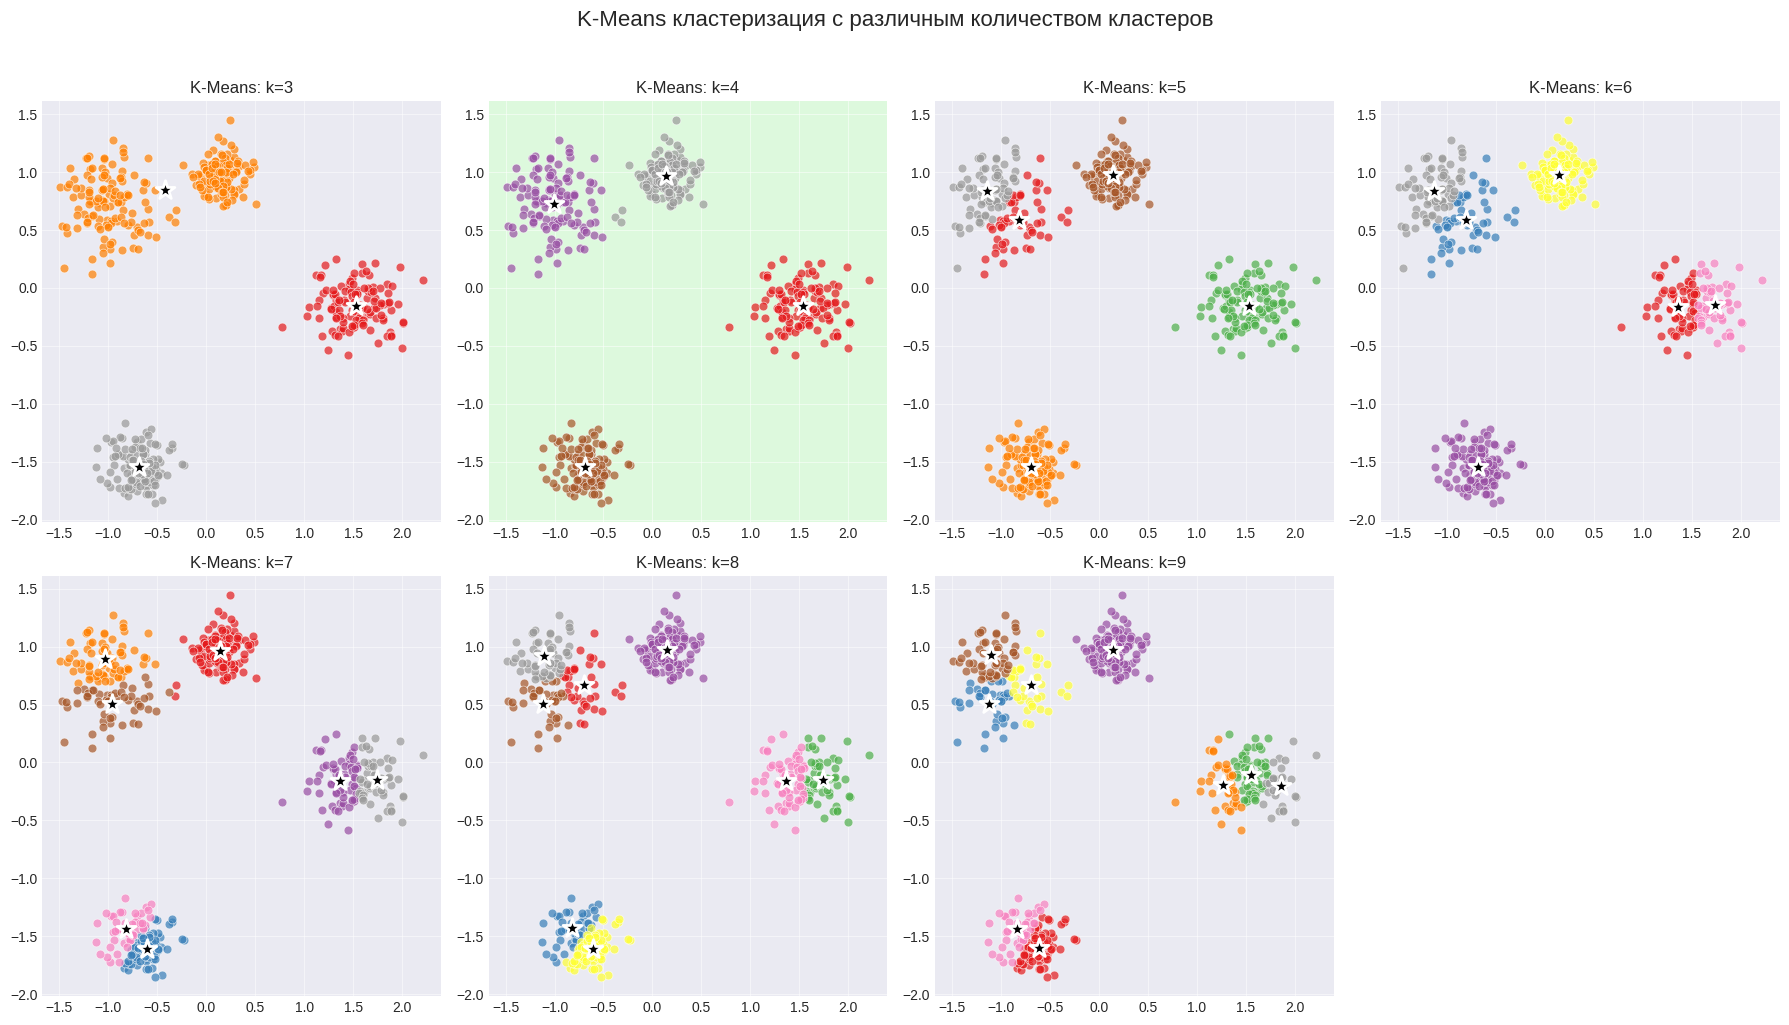

In [ ]:
# k-means с разными значениями параметра

k_values = range(3, 10)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(X_scaled)

    plot_clustering_results(X_scaled, labels_kmeans, kmeans.cluster_centers_,
                           f'K-Means: k={k}',
                           axes[idx])

    if k == 4:
        axes[idx].patch.set_facecolor('lightgreen')
        axes[idx].patch.set_alpha(0.3)

axes[-1].remove()

plt.suptitle('K-Means кластеризация с различным количеством кластеров',
            fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 2. Пошумим!
Внесем шум в набор данных (от 1 до 10 процетов) и обучим две модели k‑Means и k‑Medoids с разным значением параметра ближайших соседей (от 3 до 9)

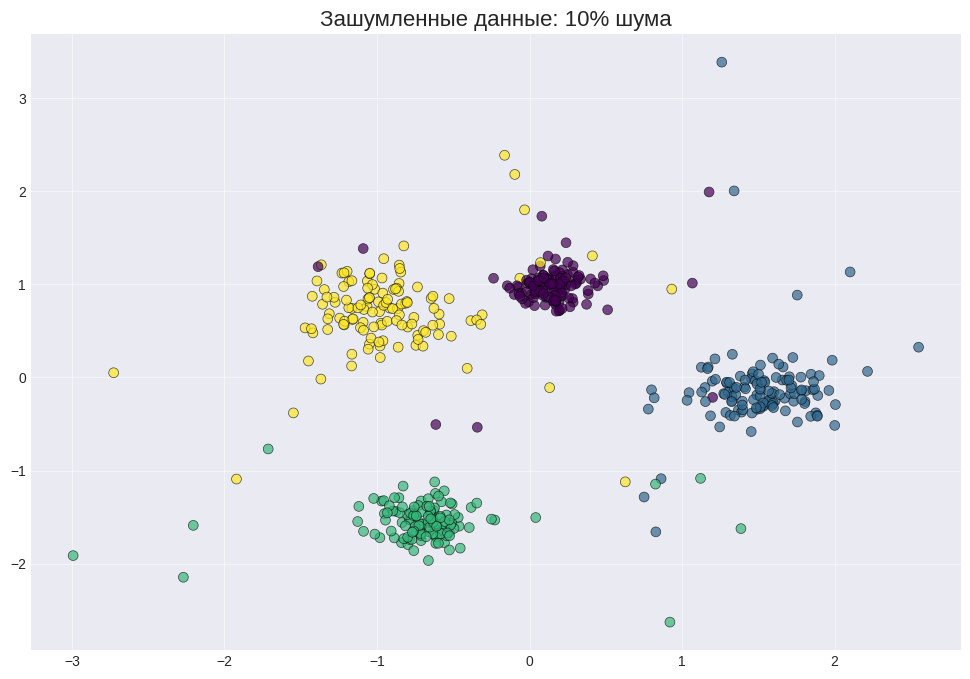

In [ ]:
# Функция добавления шума
def add_noise(data, noise_percentage, noise_magnitude=0.5):
    data_noisy = data.copy()
    n_points = len(data)
    n_noisy = int(n_points * noise_percentage / 100)

    noisy_indices = np.random.choice(n_points, n_noisy, replace=False)

    for idx in noisy_indices:
        noise = np.random.randn(data.shape[1]) * noise_magnitude
        data_noisy[idx] += noise

    return data_noisy, noisy_indices


# Выведем зашумленный график
noise_pct = 10
X_noisy, _ = add_noise(X_scaled, noise_pct, noise_magnitude=1.0)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(X_noisy[:, 0], X_noisy[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

plt.title(f'Зашумленные данные: {noise_pct}% шума', fontsize=16)
plt.grid(True, alpha=0.5)

In [ ]:
def evaluate_clustering(X, y_true, labels):
    """Оценка качества кластеризации"""
    ari = adjusted_rand_score(y_true, labels)

    if len(set(labels)) > 1:
        sil = silhouette_score(X, labels)
    else:
        sil = -1

    return ari, sil

In [ ]:
# Функция обучения
def experiment_with_noise(X, y_true, noise_percentages, k_values, n_trials=5):
    results = []

    for noise_pct in noise_percentages:
        for k in k_values:
            for trial in range(n_trials):
                # Добавляем шум
                X_noisy, _ = add_noise(X, noise_pct, noise_magnitude=1.0)

                # K-Means
                kmeans = KMeans(n_clusters=k, random_state=42+trial, n_init=10)
                labels_kmeans = kmeans.fit_predict(X_noisy)
                ari_kmeans, sil_kmeans = evaluate_clustering(X_noisy, y_true, labels_kmeans)

                # K-Medoids
                kmedoids = KMedoids(n_clusters=k, random_state=42+trial, method='pam')
                labels_kmedoids = kmedoids.fit_predict(X_noisy)
                ari_kmedoids, sil_kmedoids = evaluate_clustering(X_noisy, y_true, labels_kmedoids)

                results.append({
                    'Noise_%': noise_pct,
                    'k': k,
                    'Trial': trial,
                    'Algorithm': 'K-Means',
                    'ARI': ari_kmeans,
                    'Silhouette': sil_kmeans
                })

                results.append({
                    'Noise_%': noise_pct,
                    'k': k,
                    'Trial': trial,
                    'Algorithm': 'K-Medoids',
                    'ARI': ari_kmedoids,
                    'Silhouette': sil_kmedoids
                })

    return pd.DataFrame(results)

In [ ]:
# Перебираем все варианты

noise_percentages = [0, 1, 3, 5, 10] # Процент шума
k_values = [3, 4, 5, 6, 7, 8, 9]     # Количество соседей

results_df = experiment_with_noise(X_scaled, y_true, noise_percentages, k_values, n_trials=3)

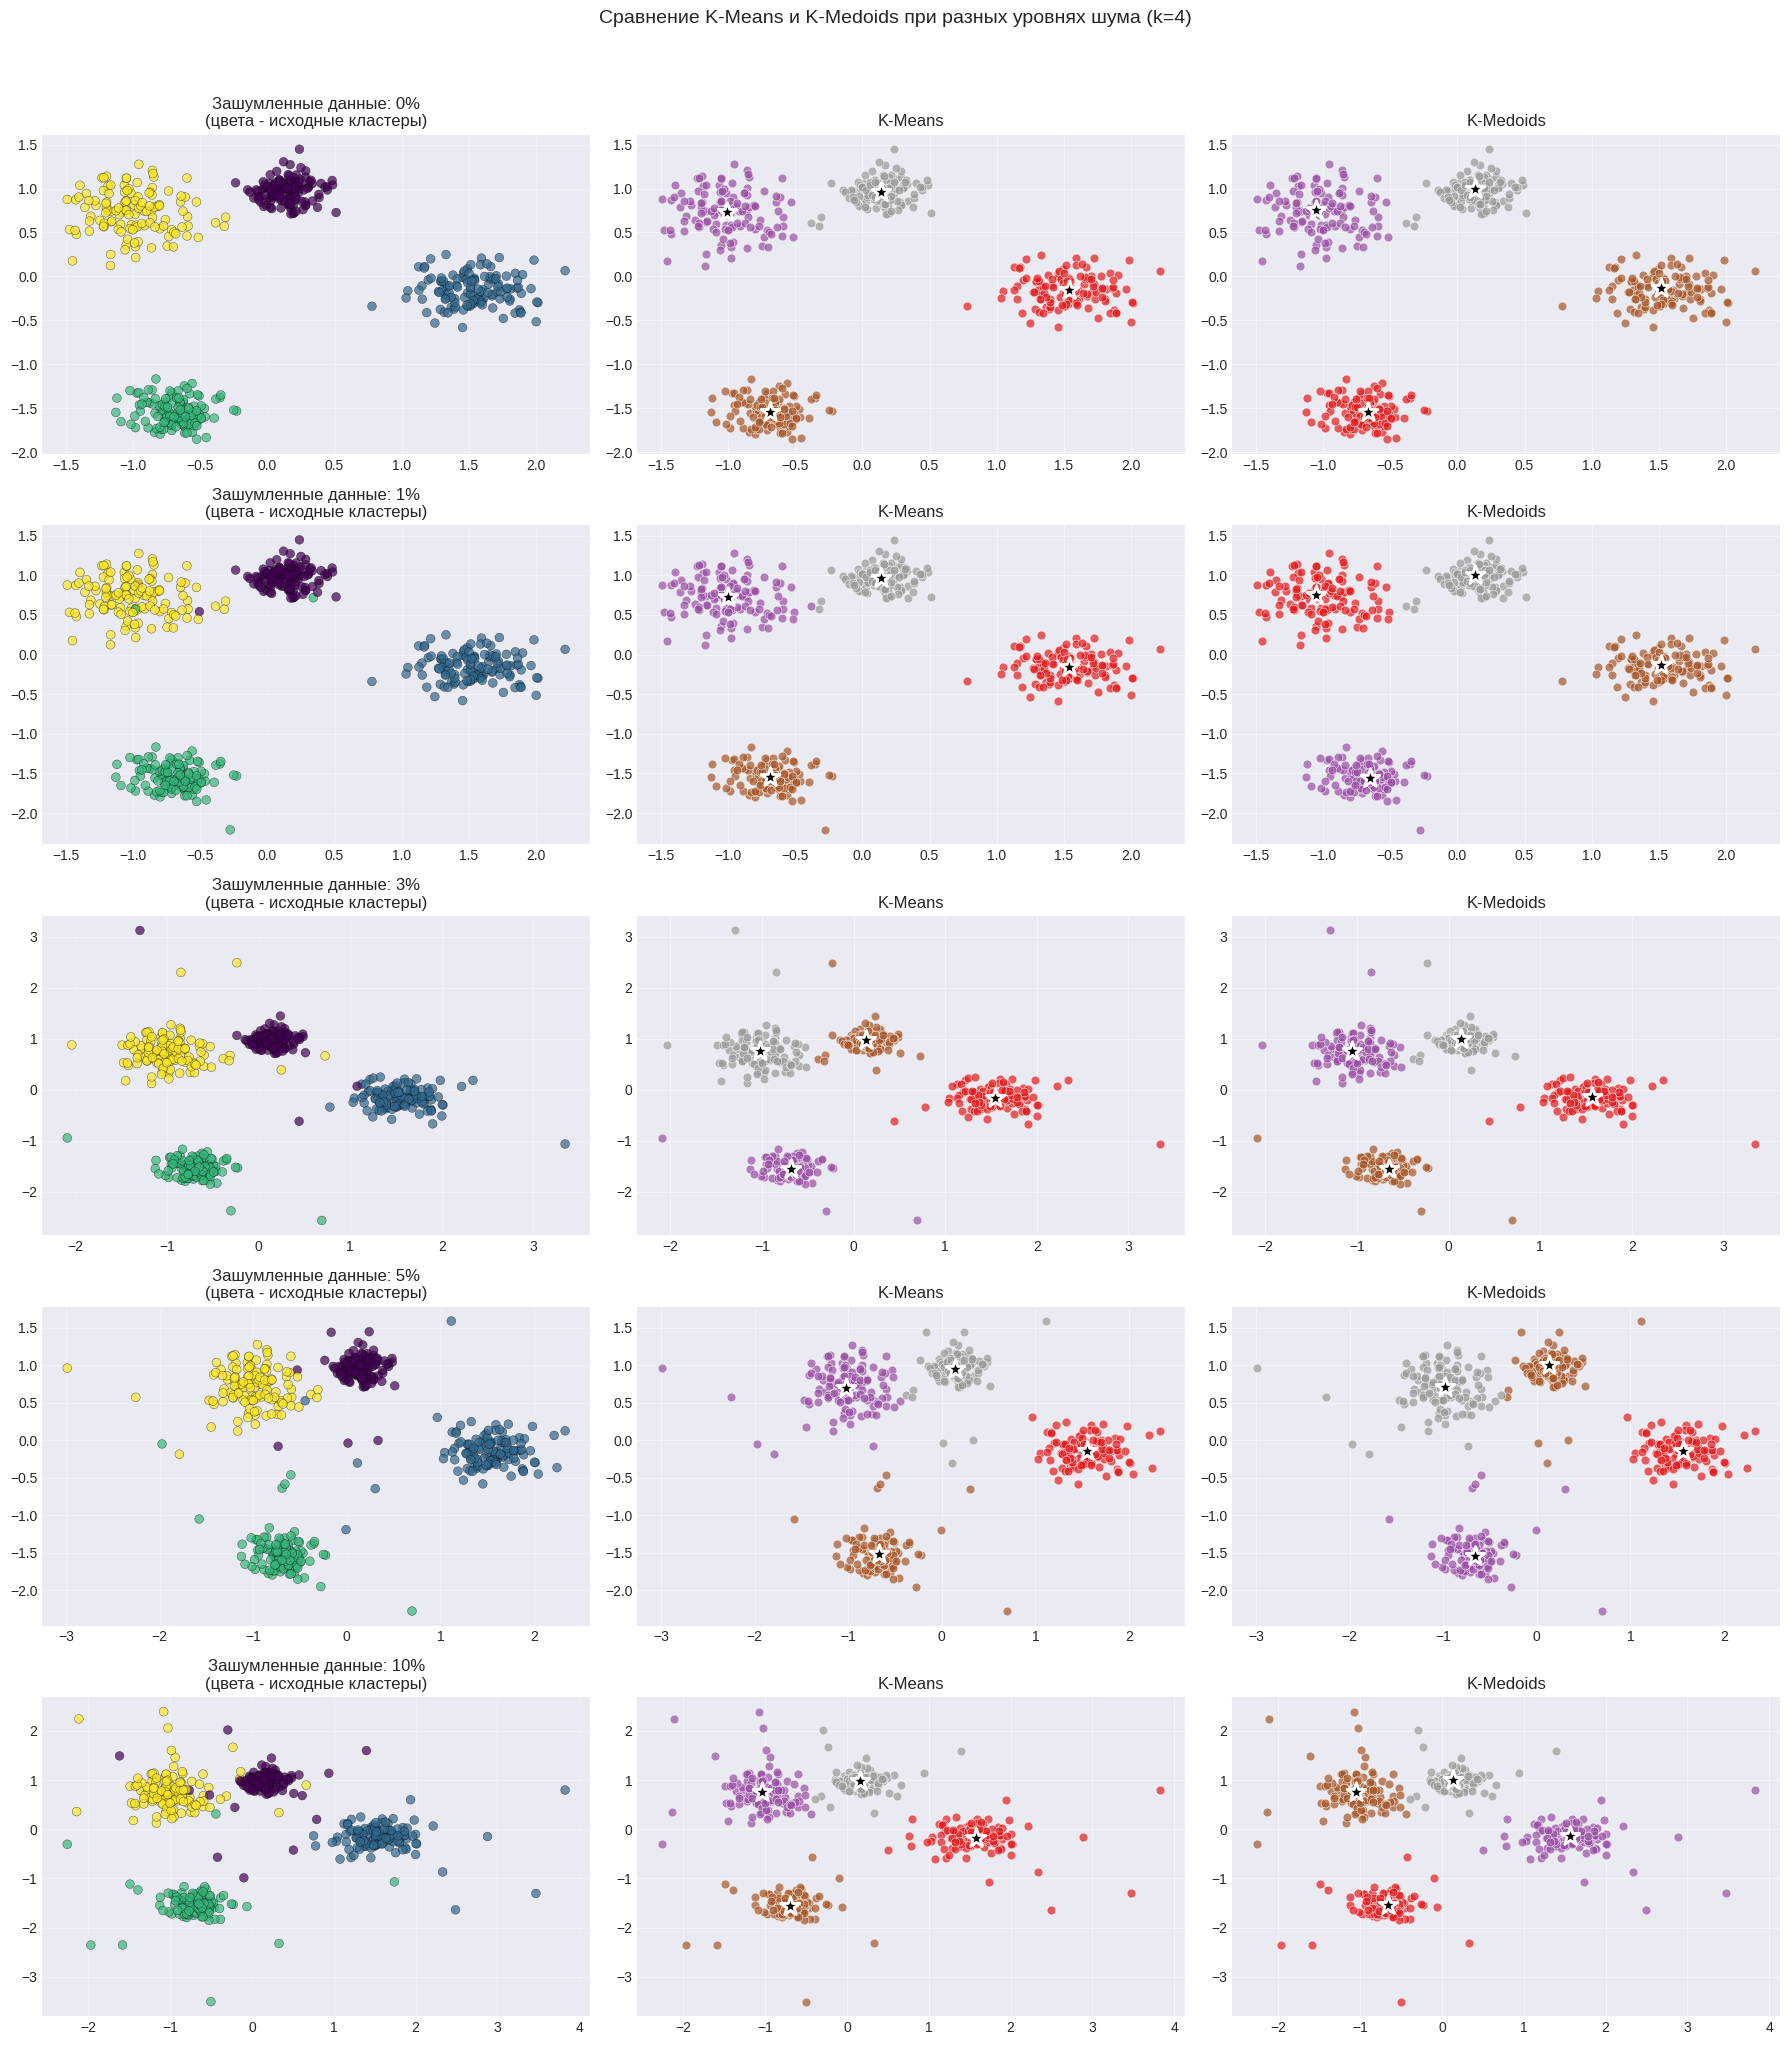

In [ ]:
# Визуализация результатов

fixed_k = 4
noise_levels = [0, 1, 3, 5, 10]

fig, axes = plt.subplots(len(noise_levels), 3, figsize=(18, 20))

for idx, noise_pct in enumerate(noise_levels):
    X_noisy, _ = add_noise(X_scaled, noise_pct, noise_magnitude=1.0)

    # K-Means
    kmeans = KMeans(n_clusters=fixed_k, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(X_noisy)

    # K-Medoids
    kmedoids = KMedoids(n_clusters=fixed_k, random_state=42, method='pam')
    labels_kmedoids = kmedoids.fit_predict(X_noisy)

    # Зашумленные данные
    scatter = axes[idx, 0].scatter(X_noisy[:, 0], X_noisy[:, 1],
                                  c=y_true, cmap='viridis',
                                  s=40, alpha=0.7, edgecolors='black', linewidth=0.3)
    axes[idx, 0].set_title(f'Зашумленные данные: {noise_pct}%\n(цвета - исходные кластеры)', fontsize=12)
    axes[idx, 0].grid(True, alpha=0.3)

    # K-Means результат
    plot_clustering_results(X_noisy, labels_kmeans, kmeans.cluster_centers_,
                          f'K-Means',
                          axes[idx, 1])

    # K-Medoids результат
    plot_clustering_results(X_noisy, labels_kmedoids, kmedoids.cluster_centers_,
                          f'K-Medoids',
                          axes[idx, 2])

plt.suptitle('Сравнение K-Means и K-Medoids при разных уровнях шума (k=4)',
            fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 3. Кластеризация набора данных из задания о "Плотностной кластеризации"
Набор данных: невыпуклые кластеры

In [ ]:
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

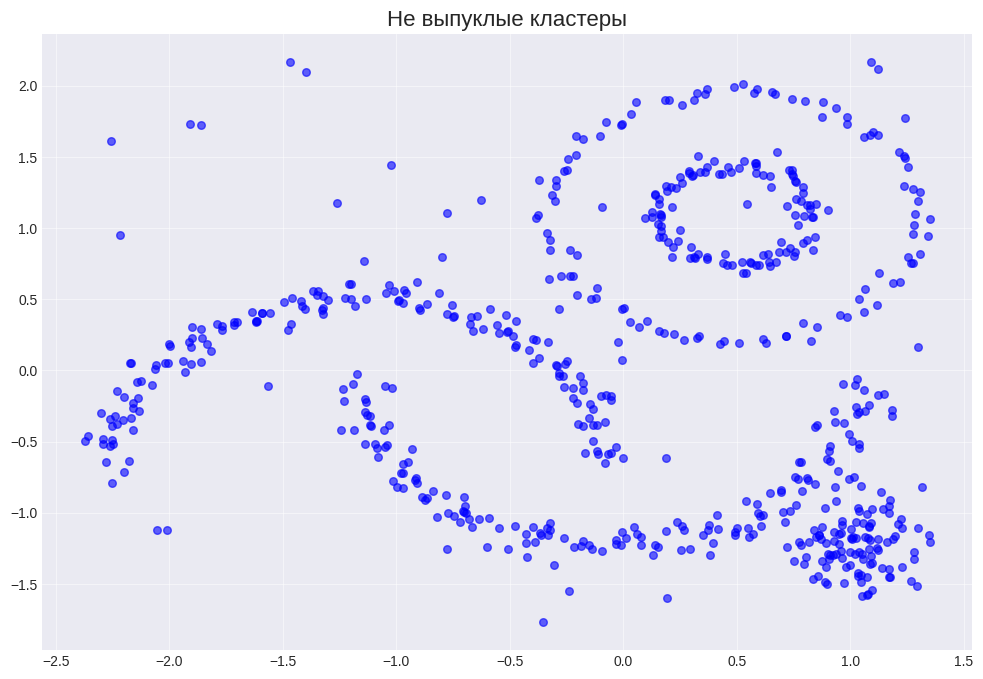

(650, 2)

In [ ]:
moons_data, moons_labels = make_moons(n_samples=300, noise=0.05, random_state=42)
moons_data = moons_data * 2
circles_data, circles_labels = make_circles(n_samples=200, noise=0.04, factor=0.4, random_state=42)
circles_data = circles_data * 1.5 + np.array([3, 3])
noise_data = np.random.uniform(low=-2, high=5, size=(50, 2))
compact_data, _ = make_blobs(n_samples=100, centers=[[4, -1]], cluster_std=0.3, random_state=42)
X2 = np.vstack([moons_data, circles_data, noise_data, compact_data])
X2 = StandardScaler().fit_transform(X2)

plt.figure(figsize=(12, 8))
plt.scatter(X2[:, 0], X2[:, 1], c='blue', alpha=0.6, s=30)
plt.title('Не выпуклые кластеры', fontsize=16)
plt.grid(True, alpha=0.5)
plt.show()

X2.shape

In [ ]:
# Функция вывода результатов
def plot_clustering_results(X, labels, centers=None, title="", ax=None):
    if ax is None:
        ax = plt.gca()

    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels[unique_labels != -1]) if -1 in unique_labels else len(unique_labels)

    colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))

    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = 'black'
            marker = 'x'
            size = 30
            alpha = 0.5
        else:
            marker = 'o'
            size = 40
            alpha = 0.8

        class_member_mask = (labels == k)
        xy = X[class_member_mask]
        ax.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=size,
                  alpha=alpha, edgecolors='white', linewidth=0.5)

    if centers is not None:
        ax.scatter(centers[:, 0], centers[:, 1], c='black', s=200,
                  marker='*', edgecolors='white', linewidth=2,
                  label='Центры' if 'Центры' not in ax.get_legend_handles_labels()[1] else "")

    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)

# Функция для оценки качества
def evaluate_clustering(X, labels):
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels[unique_labels != -1]) if -1 in unique_labels else len(unique_labels)

    if -1 in labels:
        mask = labels != -1
        X_clean = X[mask]
        labels_clean = labels[mask]
    else:
        X_clean = X
        labels_clean = labels

    metrics = {'n_clusters': n_clusters, 'n_noise': np.sum(labels == -1) if -1 in labels else 0}

    if len(np.unique(labels_clean)) > 1:
        try:
            metrics['silhouette'] = silhouette_score(X_clean, labels_clean)
        except:
            metrics['silhouette'] = -1

        try:
            metrics['davies_bouldin'] = davies_bouldin_score(X_clean, labels_clean)
        except:
            metrics['davies_bouldin'] = -1

        try:
            metrics['calinski_harabasz'] = calinski_harabasz_score(X_clean, labels_clean)
        except:
            metrics['calinski_harabasz'] = -1
    else:
        metrics['silhouette'] = -1
        metrics['davies_bouldin'] = -1
        metrics['calinski_harabasz'] = -1

    return metrics

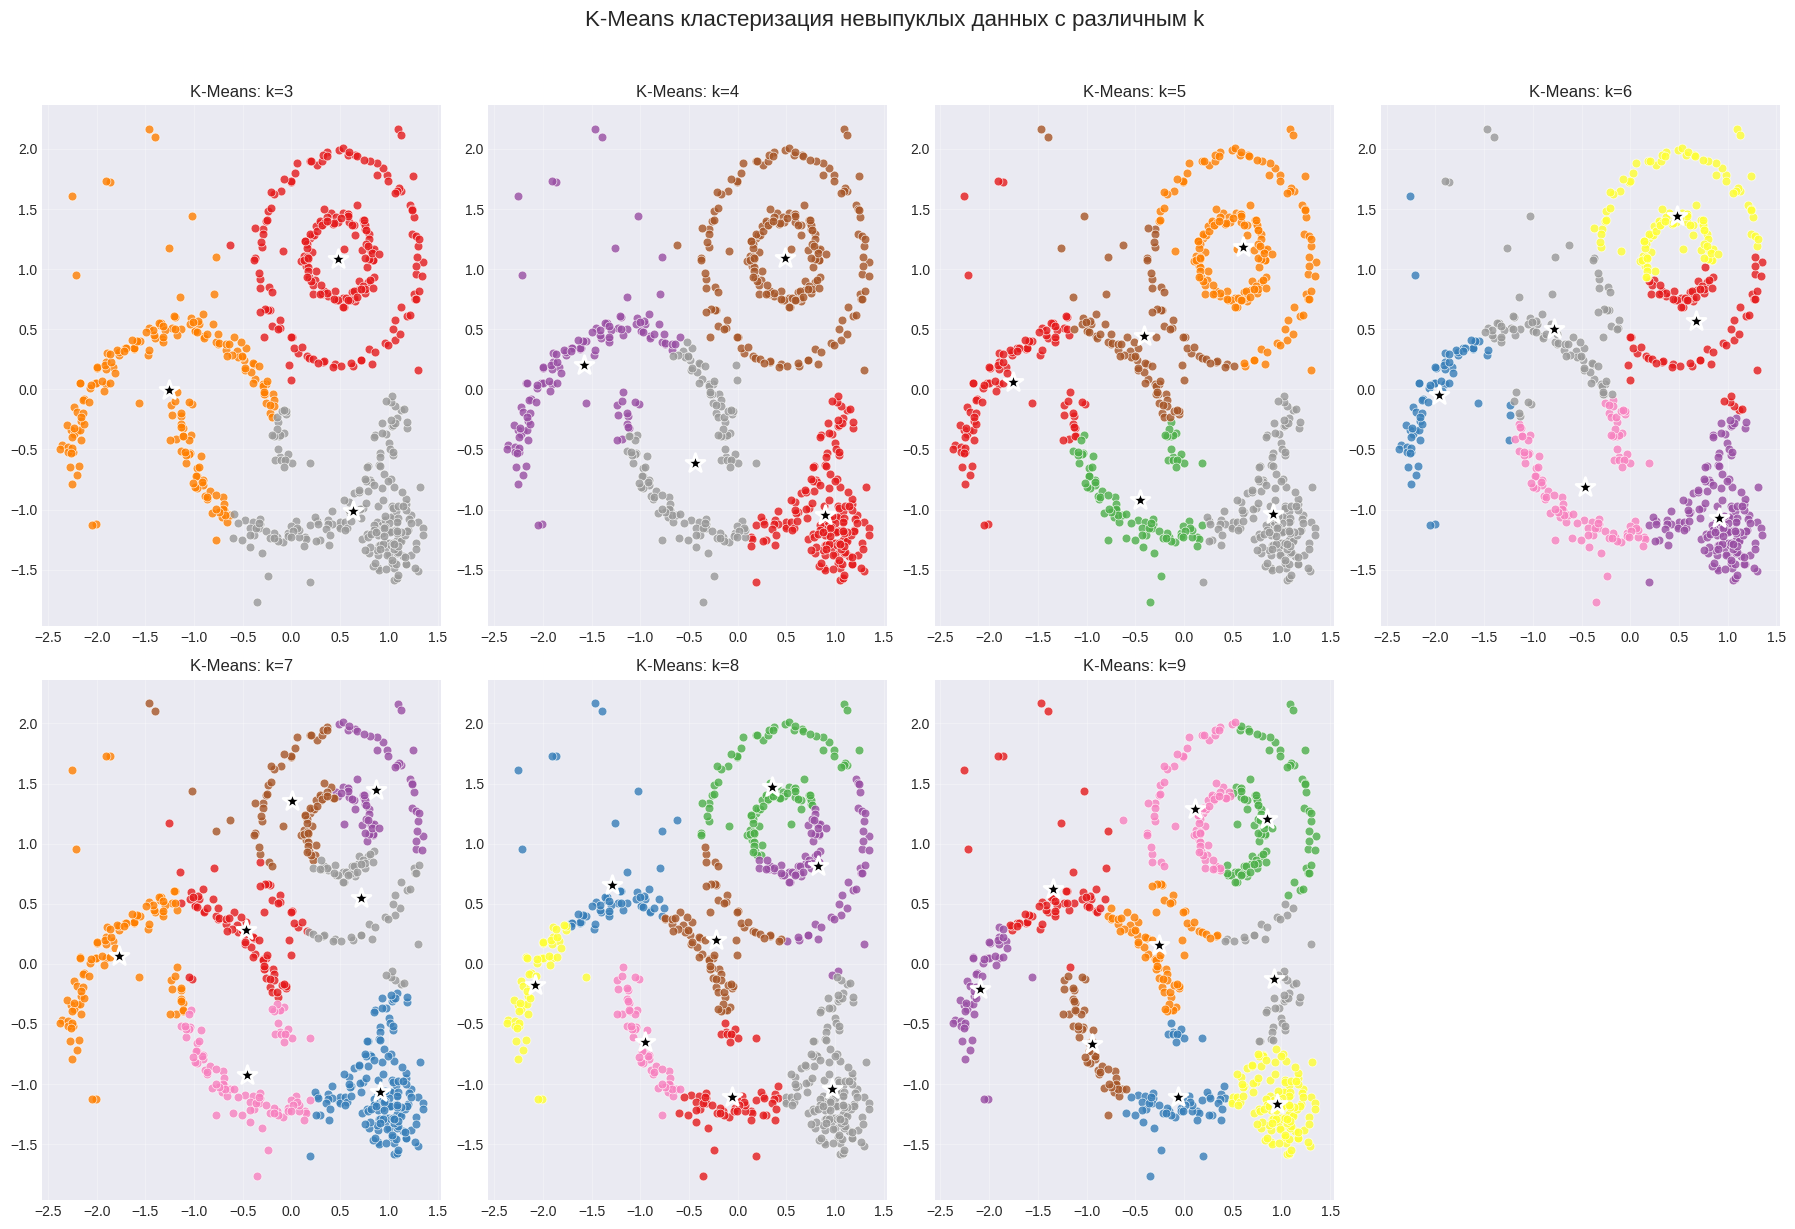

In [ ]:
# K-Means

k_values = range(3, 10)
fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(X2)

    # Визуализация
    plot_clustering_results(X2, labels_kmeans, kmeans.cluster_centers_,
                          f'K-Means: k={k}',
                          axes[idx])

axes[-1].remove()
plt.suptitle('K-Means кластеризация невыпуклых данных с различным k', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

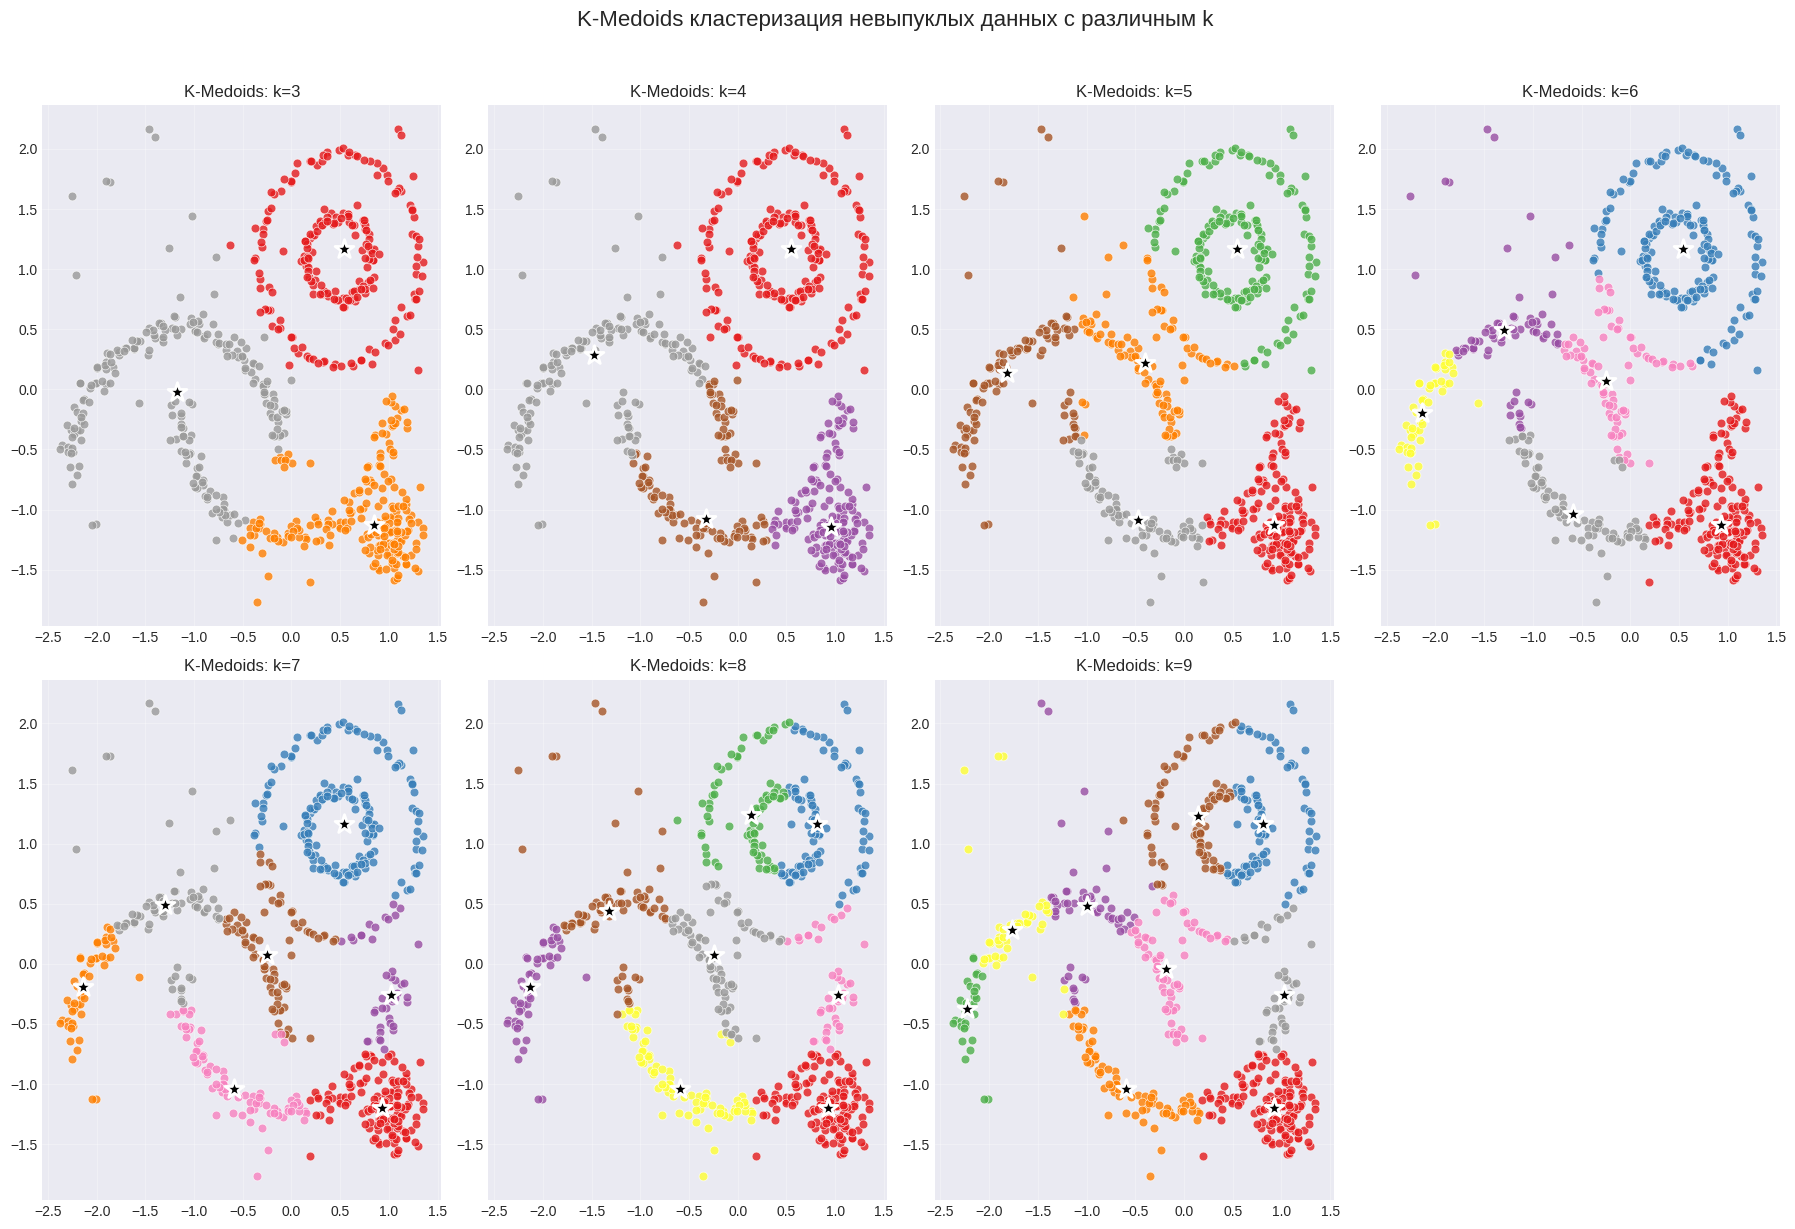

In [ ]:
# k-medoids

fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    kmedoids = KMedoids(n_clusters=k, random_state=42, method='pam')
    labels_kmedoids = kmedoids.fit_predict(X2)

    # Визуализация
    plot_clustering_results(X2, labels_kmedoids, kmedoids.cluster_centers_,
                          f'K-Medoids: k={k}',
                          axes[idx])

axes[-1].remove()
plt.suptitle('K-Medoids кластеризация невыпуклых данных с различным k', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()